# Quantitative Metrics Evaluation 

Evaluates three models / baselines using the four metrics from the GrooVAE paper:

| Metric | Description |
|--------|-------------|
| **Timing MAE** | Mean absolute error of timing offsets at hit positions |
| **Timing MSE** | Mean squared error of timing offsets at hit positions |
| **Velocity KL** | KL(pred || GT) of velocity distributions at hit positions |
| **Timing KL** | KL(pred || GT) of timing-offset distributions at hit positions |

| Row | Description |
|-----|-------------|
| **Baseline** | Fully-quantised input - offset = 0, velocity = GT velocity |
| **Dequant** | Our trained transformer |
| **GrooVAE** | Magenta GrooVAE 4-bar (optional - see install cell below) |

In [49]:
import io
import sys
import subprocess
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import pretty_midi

# Make the project root importable from within the notebooks/ directory
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.config import CONFIG
from src.data.converters.hov_converter import HOVConverter, HOVConverterConfig
from src.inference.predictor import Predictor, PredictorConfig

# Magenta requires its own .venv-magenta environment with Python3.7
# run in terminal: sudo apt install gsutil python3.7 python3.7-venv python3.7-dev libjack-jackd2-dev
!python3.7 -m venv .venv-magenta
!.venv-magenta/bin/python -m pip install --upgrade pip setuptools wheel
!.venv-magenta/bin/python -m pip install numpy==1.21.6 torch
!.venv-magenta/bin/python -m pip install note-seq magenta
MAGENTA_PYTHON = ".venv-magenta/bin/python"
MAGENTA_SCRIPT = "magenta_groovae_infer.py"

# Configuration
CHECKPOINT_PATH = ROOT / ".data/checkpoints/dequant.pt"
CHECKPOINT_PATH_L1 = ROOT / ".data/checkpoints/dequant_l1.pt"
TEST_DATA_DIR = ROOT / ".data/dataset/test"
GROOVAE_CKPT_DIR = ROOT / ".data/groovae_4bar"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Evaluation window: 64 steps = 4 bars at 4 steps/beat in 4/4 time.
# This matches the GrooVAE 4-bar model's input length exactly.
EVAL_SEQ_LEN = 64
N_SAMPLES = 500 # non-overlapping test windows to evaluate
TEMPO_BPM = 120
N_BINS = 32 # histogram bins used by the KL metrics

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

  Using cached wheel-0.42.0-py3-none-any.whl.metadata (2.2 kB)
Using cached wheel-0.42.0-py3-none-any.whl (65 kB)
  Attempting uninstall: wheel
    Found existing installation: wheel 0.37.1
    Uninstalling wheel-0.37.1:
      Successfully uninstalled wheel-0.37.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
magenta 2.1.4 requires wheel==0.37.1, but you have wheel 0.42.0 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: /home/amon/dl4ad/dequant/notebooks/.venv-magenta/bin/python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: /home/amon/dl4ad/dequant/notebooks/.venv-magenta/bin/python -m pip install --upgrade pip
  Using cached wheel-0.37.1-py2.py3-none-any.whl.metadata (2.3 kB)
Using cached wheel-0.37.1-py2.py3-none-any.whl (35 kB)
  A

## Metric Functions

All four metrics are computed **only at positions where the ground-truth hit mask is active** (`gt_hov[..., 0] > 0.5`), matching the GrooVAE paper's evaluation protocol.

KL divergence is estimated via equal-width histogram binning: `KL(pred ‖ GT)`.

> **Per-position extensibility:** `compute_all_metrics` retains the full `(N, T, instruments)` arrays before reducing. To add per-position curves later, apply the metric functions along `axis=(0, 2)` instead of flattening - no restructuring needed.

In [41]:
def timing_mae(pred_offsets: np.ndarray, gt_offsets: np.ndarray, hit_mask: np.ndarray) -> float:
    """Mean absolute timing-offset error at hit positions (GrooVAE paper §4.1)."""
    return float(np.abs(pred_offsets[hit_mask] - gt_offsets[hit_mask]).mean())


def timing_mse(pred_offsets: np.ndarray, gt_offsets: np.ndarray, hit_mask: np.ndarray) -> float:
    """Mean squared timing-offset error at hit positions."""
    return float(((pred_offsets[hit_mask] - gt_offsets[hit_mask]) ** 2).mean())


def _kl_divergence(p_vals: np.ndarray, q_vals: np.ndarray, n_bins: int, val_range: tuple) -> float:
    """
    KL(p || q) estimated from samples via equal-width histogram binning.
    A small epsilon is added to every bin to avoid log(0).
    """
    eps = 1e-10
    bins = np.linspace(val_range[0], val_range[1], n_bins + 1)
    p_hist, _ = np.histogram(p_vals, bins=bins)
    q_hist, _ = np.histogram(q_vals, bins=bins)
    p = (p_hist + eps) / (p_hist.sum() + eps * n_bins)
    q = (q_hist + eps) / (q_hist.sum() + eps * n_bins)
    return float(np.sum(p * np.log(p / q)))


def velocity_kl(pred_ov: np.ndarray, gt_hov: np.ndarray, hit_mask: np.ndarray,
                n_bins: int = N_BINS) -> float:
    """KL(pred_vel || gt_vel) at hit positions, velocities in [0, 1]."""
    return _kl_divergence(
        pred_ov[..., 1][hit_mask], gt_hov[..., 2][hit_mask], n_bins, (0.0, 1.0)
    )


def timing_kl(pred_ov: np.ndarray, gt_hov: np.ndarray, hit_mask: np.ndarray,
              n_bins: int = N_BINS) -> float:
    """KL(pred_offset || gt_offset) at hit positions, offsets in [-0.5, 0.5]."""
    return _kl_divergence(
        pred_ov[..., 0][hit_mask], gt_hov[..., 1][hit_mask], n_bins, (-0.5, 0.5)
    )


def compute_all_metrics(pred_ov: np.ndarray, gt_hov: np.ndarray) -> dict:
    """
    Compute all four GrooVAE metrics for a collection of sequences.

    Args:
        pred_ov:  Predicted (offset, velocity),  shape (N, T, instruments, 2).
        gt_hov:   Ground-truth HOV,              shape (N, T, instruments, 3).

    Returns:
        Dict mapping metric name -> scalar value.

    Per-position extension (future work):
        Replace `[hit_mask]` flat-indexing with masked reductions along specific
        axes to get (T,) curves without changing the function signatures.
    """
    hit_mask = gt_hov[..., 0] > 0.5   # (N, T, instruments)

    return {
        "Timing MAE":  timing_mae(pred_ov[..., 0],  gt_hov[..., 1], hit_mask),
        "Timing MSE":  timing_mse(pred_ov[..., 0],  gt_hov[..., 1], hit_mask),
        "Velocity KL": velocity_kl(pred_ov, gt_hov, hit_mask),
        "Timing KL":   timing_kl(pred_ov,   gt_hov, hit_mask),
    }

## Load Test Data

In [50]:
def load_test_sequences(data_dir: Path, n_samples: int, seq_len: int = EVAL_SEQ_LEN, seed: int = 42) -> np.ndarray:
    """
    Load one random HOV window per track from test-split npz files, then
    stop once n_samples are collected. Taking one window per track ensures
    diversity across performers rather than sampling many windows from the
    same repetitive recording.

    Returns:
        np.ndarray of shape (n_samples, seq_len, num_instruments, 3).
    """
    rng = np.random.default_rng(seed)
    sequences = []
    npz_files = sorted(data_dir.glob("*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No .npz files in {data_dir} - run preprocess first.")

    for npz_path in npz_files:
        with np.load(npz_path, allow_pickle=True) as f:
            for track in f["data"]:
                if track is None or len(track) < seq_len:
                    continue
                # One random window per track keeps samples diverse across performers
                max_start = len(track) - seq_len
                start = int(rng.integers(0, max_start + 1))
                sequences.append(track[start : start + seq_len])
                if len(sequences) >= n_samples:
                    break
        if len(sequences) >= n_samples:
            break

    if len(sequences) < n_samples:
        raise ValueError(f"Only {len(sequences)} usable tracks found, need {n_samples}.")

    gt = np.stack(sequences).astype(np.float32)
    print(f"Loaded {len(gt)} test sequences  shape={gt.shape}")
    return gt


gt_hov = load_test_sequences(TEST_DATA_DIR, N_SAMPLES)

Loaded 500 test sequences  shape=(500, 64, 9, 3)


## Baseline Inference
*Cache cell - skip re-running if `pred_baseline` already exists.*

The baseline is the fully-quantised input: timing offset = 0 for every hit, velocity copied from ground truth. This represents the input signal before any humanisation model is applied.

In [52]:
def run_baseline(gt_hov: np.ndarray) -> np.ndarray:
    """
    Fully-quantised baseline: offset = 0, velocity = GT velocity.
    Shape: (N, T, instruments, 2).
    """
    pred_ov = np.zeros((*gt_hov.shape[:3], 2), dtype=np.float32)
    pred_ov[..., 1] = np.mean(gt_hov[..., 2], where=(gt_hov[..., 0] > 0.5))   # use average velocity
    return pred_ov


pred_baseline = run_baseline(gt_hov)
print(f"Baseline {pred_baseline.shape}")

Baseline (500, 64, 9, 2)


## Dequant Model Inference
*Cache cell - skip re-running if `pred_dequant` already exists.*

Feeds the hit-only sequence into `Predictor.process_sequence()` and extracts the predicted (offset, velocity) output.

In [54]:
pred_dequant_l1 = None
pred_dequant = None

def run_dequant(gt_hov: np.ndarray, checkpoint_path: Path, device: str) -> np.ndarray:
    """
    Run the Dequant transformer on each test sequence.

    Input:  hit mask from gt_hov[..., 0]   shape (T, instruments).
    Output: predicted (offset, velocity),  shape (N, T, instruments, 2).
    """
    predictor = Predictor(PredictorConfig(checkpoint=checkpoint_path, model=CONFIG.model))
    predictor.model.eval()

    T = gt_hov.shape[1]
    predictions = []

    for i, hov in enumerate(gt_hov):
        print(f"Infering {i + 1}/{len(gt_hov)}")
        hits = torch.from_numpy(hov[..., 0]).float()   # (T, instruments)
        predictor.reset()
        result = predictor.process_sequence(hits)       # (T, instruments, 3)
        ov = result[:, :, 1:3].cpu().numpy()            # (T, instruments, 2)

        # Pad to EVAL_SEQ_LEN if the predictor returned a shorter window
        if len(ov) < T:
            pad = np.zeros((T - len(ov), *ov.shape[1:]), dtype=np.float32)
            ov = np.concatenate([ov, pad], axis=0)
        predictions.append(ov[:T])

    pred_ov = np.stack(predictions).astype(np.float32)
    print(f"Dequant {pred_ov.shape}")
    return pred_ov


CONFIG.model.transformer.n_layers = 1
pred_dequant_l1 = run_dequant(gt_hov, CHECKPOINT_PATH_L1, DEVICE)

CONFIG.model.transformer.n_layers = 5
pred_dequant = run_dequant(gt_hov, CHECKPOINT_PATH, DEVICE)

INFO: checkpoint.py:48: Loading checkpoint from /home/amon/dl4ad/dequant/.data/checkpoints/dequant_l1.pt ...
INFO: predictor.py:143: Predicting 64 steps ...
INFO: predictor.py:143: Predicting 64 steps ...
INFO: predictor.py:143: Predicting 64 steps ...
INFO: predictor.py:143: Predicting 64 steps ...


Infering 1/500
Infering 2/500
Infering 3/500
Infering 4/500


INFO: predictor.py:143: Predicting 64 steps ...
INFO: predictor.py:143: Predicting 64 steps ...
INFO: predictor.py:143: Predicting 64 steps ...


Infering 5/500
Infering 6/500
Infering 7/500


INFO: predictor.py:143: Predicting 64 steps ...
INFO: predictor.py:143: Predicting 64 steps ...
INFO: predictor.py:143: Predicting 64 steps ...
INFO: predictor.py:143: Predicting 64 steps ...


...

Infering 498/500


INFO: predictor.py:143: Predicting 64 steps ...


Infering 499/500


INFO: predictor.py:143: Predicting 64 steps ...


Infering 500/500
Dequant (500, 64, 9, 2)


## GrooVAE Inference
*Cache cell (optional) - requires `magenta` + `note-seq`. Skip if `GROOVAE_AVAILABLE` is False.*

Each HOV sequence is:
1. Converted to a **quantised** PrettyMIDI (timing offsets zeroed out) via the existing `HOVConverter`
2. Fed through GrooVAE encode → decode (reconstruction = humanisation)
3. Converted back to HOV via `HOVConverter.midi_to_hov`, extracting the predicted (offset, velocity)

The checkpoint is downloaded automatically to `GROOVAE_CKPT_DIR` on first run.

In [51]:
import base64

# Download the model:
# !curl -O https://storage.googleapis.com/magentadata/models/music_vae/checkpoints/groovae_4bar.tar
# !tar -xf groovae_4bar.tar

def run_groovae_external(gt_hov):
    _B, T, I, _3 = gt_hov.shape

    converter = HOVConverter(HOVConverterConfig(
        steps_per_beat=CONFIG.model.drums.steps_per_beat,
        categories=CONFIG.model.drums.categories,
        max_seq_len=CONFIG.model.max_seq_len,
    ))

    # Encode prettymidi
    input_midis: list[str] = []
    for hov in gt_hov:
        quantised = hov.copy()
        quantised[..., 1] = 0.0

        # Convert HOV to to base64-encoded midi file
        midi_obj = converter.hov_to_midi(quantised, tempo_bpm=TEMPO_BPM)
        midi_buf = io.BytesIO()
        midi_obj.write(midi_buf)
        midi_b64 = base64.b64encode(midi_buf.getvalue()).decode()

        input_midis.append(midi_b64)

    # Invoke magenta with Python 3.7
    payload = {
        "input_midis": input_midis,
        "ckpt_dir": str(GROOVAE_CKPT_DIR),
        "eval_seq_len": EVAL_SEQ_LEN,
    }

    process = subprocess.Popen(
        [MAGENTA_PYTHON, MAGENTA_SCRIPT],
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    stdout, stderr = process.communicate(json.dumps(payload))

    # print(stderr)
    if process.returncode != 0:
        raise RuntimeError(f"Magenta failed:\n{stderr}")

    output_midis = json.loads(stdout)
    predictions = []

    for midi_b64 in output_midis:
        midi_data = base64.b64decode(midi_b64)

        try:
            buf = io.BytesIO()
            buf.write(midi_data)
            buf.seek(0)
            midi_obj = pretty_midi.PrettyMIDI(buf)
            result_hov, _ = converter.midi_to_hov(midi_obj, tempo_bpm=TEMPO_BPM)

            t = min(len(result_hov), T)
            ov = np.zeros((T, I, 2), dtype=np.float32)
            ov[:t] = result_hov[:t, :, 1:3]
            predictions.append(ov)

        except Exception as e:
            raise RuntimeError(f"Warning: MIDI conversion failed ({e})")

    return np.stack(predictions).astype(np.float32)

pred_groovae = run_groovae_external(gt_hov)
print(f"GrooVAE {pred_groovae.shape}")

GrooVAE (500, 64, 9, 2)


## Results

In [55]:
# Collect all predictions
model_preds = {
    "Baseline": pred_baseline,
    "Dequant":  pred_dequant,
}
if pred_dequant_l1 is not None:
    model_preds["Dequant (L1)"] = pred_dequant_l1
if pred_groovae is not None:
    model_preds["GrooVAE"] = pred_groovae

metrics = {name: compute_all_metrics(pred, gt_hov) for name, pred in model_preds.items()}

df = pd.DataFrame(metrics).T
df.index.name = "Model"

df.style \
    .format("{:.4f}") \
    .set_caption(f"GrooVAE Metrics - {N_SAMPLES} test sequences") \
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "1.1em"), ("padding-bottom", "6px")]},
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 12px")]},
    ])

,Timing MAE,Timing MSE,Velocity KL,Timing KL
Model,,,,
Baseline,0.1409,0.0338,3.0439,2.6243
Dequant,0.1517,0.0379,0.0650,0.0958
Dequant (L1),0.1368,0.0311,0.5688,0.7269
GrooVAE,0.1389,0.0333,17.1983,1.0042


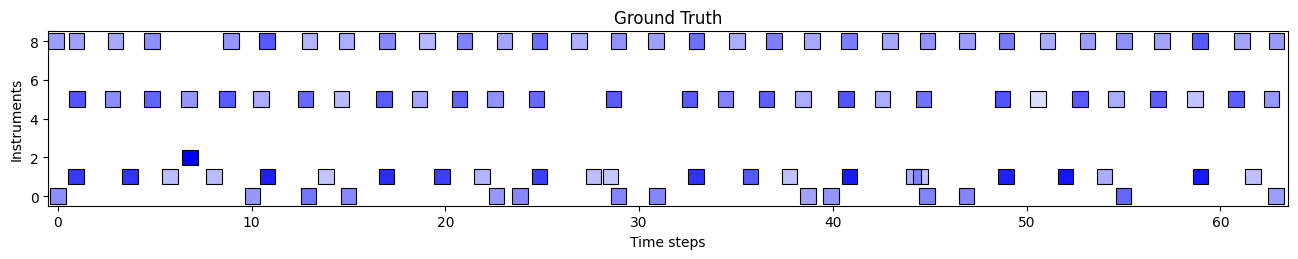

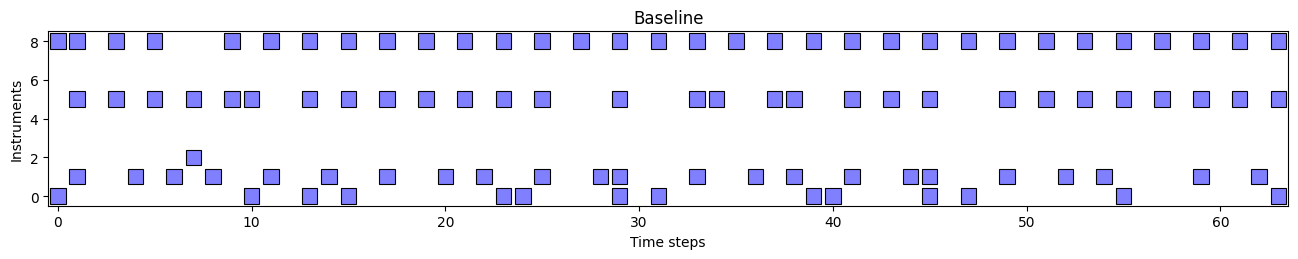

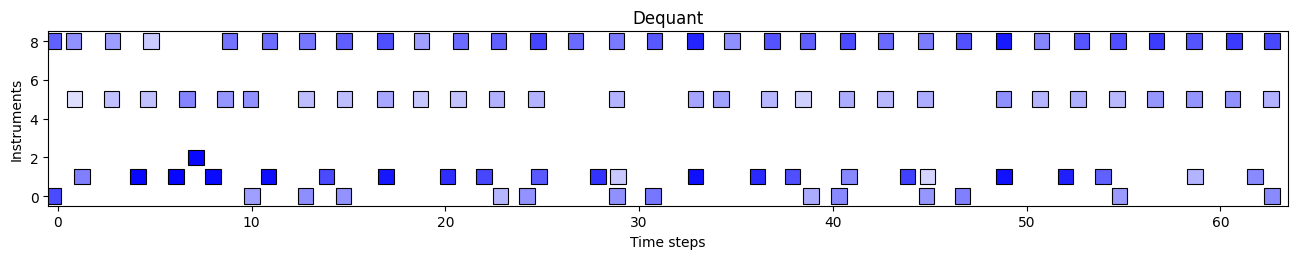

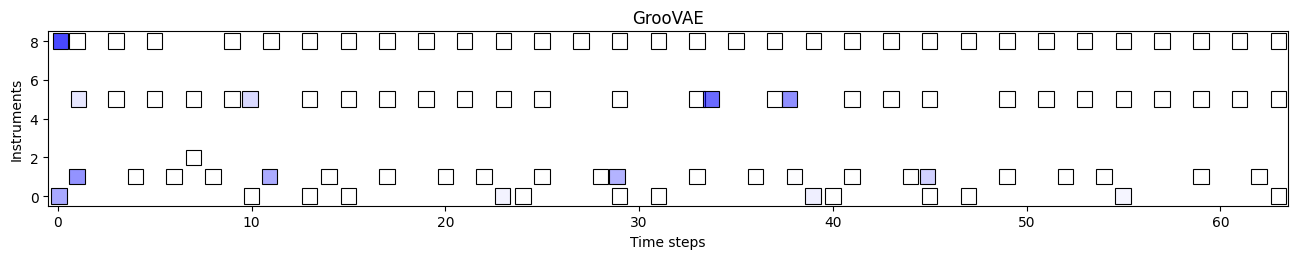

In [60]:
import matplotlib.pyplot as plt

def plot_hov(hov: np.ndarray, title="HOV Tensor"):
    """
    Plot a HOV tensor of shape (T, I, 3)
    hov[..., 0] -> hit (0/1)
    hov[..., 1] -> x-offset (-0.5..0.5)
    hov[..., 2] -> velocity (0..1)
    """
    T, I, _ = hov.shape
    fig, ax = plt.subplots(figsize=(T/4, I/2))

    rect_width = 0.8
    rect_height = 0.8

    for t in range(T):
        for i in range(I):
            hit, offset, velocity = hov[t, i]
            if hit > 0:
                x = t + offset - rect_width/2
                y = i - rect_height/2

                # fill
                rect = plt.Rectangle(
                    (x, y),
                    rect_width,
                    rect_height,
                    facecolor='blue',
                    alpha=float(np.clip(velocity, 0.0, 1.0)),
                    edgecolor=None
                )
                ax.add_patch(rect)

                # outline
                rect_outline = plt.Rectangle(
                    (x, y),
                    rect_width,
                    rect_height,
                    facecolor='none',
                    edgecolor='black',
                    linewidth=0.8
                )
                ax.add_patch(rect_outline)
    
    ax.set_xlim(-0.5, T-0.5)
    ax.set_ylim(-0.5, I-0.5)
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Instruments")
    ax.yaxis.set_inverted(True)
    ax.set_title(title)
    ax.set_aspect('equal')
    plt.gca().invert_yaxis()  # optional: top instrument at top
    plt.show()

index = 5
plot_hov(gt_hov[index], "Ground Truth")
plot_hov(np.concatenate([gt_hov[..., :1], pred_baseline], axis=-1)[index], "Baseline")
plot_hov(np.concatenate([gt_hov[..., :1], pred_dequant], axis=-1)[index], "Dequant")
plot_hov(np.concatenate([gt_hov[..., :1], pred_groovae], axis=-1)[index], "GrooVAE")